<a href="https://colab.research.google.com/github/abudofa2017-lgtm/Pharmacovigilance-data-practice-/blob/main/GROUP_2_Capstone_Project_WAEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Topic: WAEC Performance Trend and Prediction for West African Students Over the Next 15 years


#### Introduction : The West AFrican Examination Council - WAEC is is a regional examining board established in 1952 to conduct standardized examinations, specifically the West African Senior School Certificate Examination (WASSCE), in English-speaking West African countries, including Nigeria, Ghana, Sierra Leone, The Gambia, and Liberia. it includes the following Key functions and Fact

* **Member Countries:** Nigeria, Ghana, Sierra Leone, The Gambia, and Liberia.
* **Examination:**  Conducts the West African Senior School Certificate Examination (WASSCE) for both school candidates and private candidates (GCE).
* **Purpose**: To conduct examinations in the public interest, award internationally recognized certificates, and maintain educational standards.
* **Result Verification:** Results are accessible online via the WAECDirect portal.
*  **Modernization:** As of 2026, WAEC is transitioning to conducting the WASSCE as a computer-based test (CBT).


### AIM
To analyse historical WAEC examination performance across selected West African countries, identify performance trends and key influencing factors, and forecast future performance patterns over the next 15 years using statistical and machine‑learning techniques.
### Specific Objectives



1. To perform exploratory data analysis (EDA) on WAEC results from the past 15 years to uncover trends, distributions, and disparities in student performance.
2. To compare WAEC performance across countries, school types, gender, student tracks, and regions using benchmark and average credit metrics.
4. To forecast aggregate WAEC performance trends over the next 15 years and assess possible future outcomes if current trends persist.



## Importing the libraries

In [ ]:
!pip install xgboost

In [ ]:
!pip install prophet

In [ ]:
#importing the necessart libraies for for Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
# libries used for modeling and Encodinf
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error,classification_report, roc_auc_score
from sklearn.model_selection import train_test_split,GridSearchCV
from xgboost import XGBClassifier
# libries used for Forcasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.compose import ColumnTransformer
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
import re


In [ ]:
# Connecting to the dataset on my Google drive

# Paste your full shareable link here but make sure you set the link to "Anyone with the link can view"
share_link = "https://drive.google.com/file/d/1Hbo2FrPC1MbKIuSXjn4d9j4dJmFhOWWk/view?usp=drivesdk"

# Automatically extract the ID and create the direct download URL
file_id = share_link.split('/')[-2]
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# read into pandas the direct url
waec_data = pd.read_csv(direct_url)

Data Preprocessing

## Data Exploration

In [ ]:
# Understand the structure by viewing the rows
waec_data.head()

,student_id,country,exam_year,exam_type,student_track,school_name,school_state_region,school_country_region,school_type,subject_math,subject_english,subject_biology,subject_chemistry,subject_physics,subject_further_math,subject_agric,subject_literature,subject_government,subject_history,subject_crs_irs,subject_yoruba_igbo_hausa,subject_economics,subject_commerce,subject_accounts,subject_phe,total_credits,percentage_score_math,exam_date,registration_fee,gender,is_resit,passed_benchmark
0,WAEC-2020-06817,Nigeria,2020,Handwritten,Science,Police Secondary School (Main Campus),Osun,South West,Pvt,B3,C6,B2,C4,B3,B2,B2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B3,8.0,74.2,2020/05/05,27495,Female,No,Yes
1,waec201411278,ghana,2014,Handwritten,Commercial,Holy Child SHS,Brong-Ahafo,Middle Belt Ghana,Intrnational,B2,C5,NaN,NaN,NaN,NaN,NaN,NaN,E8,NaN,C4,NaN,B2,E8,B3,NaN,5.0,79.6,02/05/2014,787,Female,No,Yes
2,WAEC/2015/08243,Liberia,2015,Handwritten,Arts,Maryland County High Annex,Grand Cape Mount,Western,Military,B3,B3,NaN,NaN,NaN,NaN,NaN,D7,D7,C6,B3,NaN,NaN,NaN,NaN,E8,4.0,80.6,05-11-2015,5956,Female,No,No
3,WAEC-2017-09844,Nígeria,2017,Handwritten,Commercial,Baptist High School,Bayelsa,South South,Public,C4,D7,NaN,NaN,NaN,NaN,NaN,NaN,C6,NaN,C4,NaN,F9,C4,B3,B3,6.0,63.2,NaN,25188,Female,No,No
4,WAEC/2022/14444,nigeria,2022,Handwritten,Science,Our Lady of Apostles,Lagos,South West,Military,C6,C5,A1,C4,C5,B2,C5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A1,8.0,56.1,22/05/2022,25213,Male,No,Yes


In [ ]:
# understanding and viewing the number of rows and column in the dataset
waec_data.shape

(15115, 32)

In [ ]:
# getting the summary Statistics of the Dataset
waec_data.describe()

,exam_year,total_credits,percentage_score_math,registration_fee
count,15115.000000,14970.000000,15115.000000,15115.000000
mean,2017.878597,5.509820,59.388614,20079.361231
std,4.264699,1.592056,18.957281,39933.500588
min,2010.000000,0.000000,-10.000000,0.000000
25%,2014.000000,4.000000,46.900000,3599.000000
50%,2018.000000,6.000000,60.200000,16636.000000
75%,2022.000000,7.000000,73.400000,24017.000000
max,2024.000000,10.000000,200.000000,1000000.000000


In [ ]:
# Viewing the dataset to understand the columns, number of rows and the datatype
waec_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15115 entries, 0 to 15114
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 15115 non-null  object 
 1   country                    15115 non-null  object 
 2   exam_year                  15115 non-null  int64  
 3   exam_type                  15115 non-null  object 
 4   student_track              15115 non-null  object 
 5   school_name                15115 non-null  object 
 6   school_state_region        15115 non-null  object 
 7   school_country_region      15115 non-null  object 
 8   school_type                14653 non-null  object 
 9   subject_math               14348 non-null  object 
 10  subject_english            15115 non-null  object 
 11  subject_biology            3711 non-null   object 
 12  subject_chemistry          3711 non-null   object 
 13  subject_physics            3711 non-null   obj

## Data Cleaning

In [ ]:
#  Checking the number of row with missing values
waec_data.isnull().sum()

,0
student_id,0
country,0
exam_year,0
exam_type,0
student_track,0
school_name,0
school_state_region,0
school_country_region,0
school_type,462
subject_math,767


In [ ]:
# checking the percentage of the missing values in the dataset and round to 2 decimal place
missing_percentage = (waec_data.isnull().mean()*100).round(2)
print(missing_percentage)

student_id                    0.00
country                       0.00
exam_year                     0.00
exam_type                     0.00
student_track                 0.00
school_name                   0.00
school_state_region           0.00
school_country_region         0.00
school_type                   3.06
subject_math                  5.07
subject_english               0.00
subject_biology              75.45
subject_chemistry            75.45
subject_physics              75.45
subject_further_math         75.45
subject_agric                75.45
subject_literature           65.39
subject_government           24.55
subject_history              65.39
subject_crs_irs              24.55
subject_yoruba_igbo_hausa    75.67
subject_economics            59.17
subject_commerce             59.17
subject_accounts             59.17
subject_phe                   9.65
total_credits                 0.96
percentage_score_math         0.00
exam_date                     2.02
registration_fee    

**Remove Duplicate Rows**

In [ ]:
# Checking for duplicate
waec_data_duplicate = waec_data.duplicated().sum()
print(f"There are {waec_data_duplicate} duplicate rows in the dataset")

There are 15 duplicate rows in the dataset


In [ ]:
# Drop the duplicates rows
waec_data.drop_duplicates(inplace = True)

In [ ]:
waec_data.shape

(15100, 32)

In [ ]:
# checking each uniques values in the column
waec_data.nunique()

,0
student_id,15000
country,59
exam_year,15
exam_type,2
student_track,3
school_name,1272
school_state_region,199
school_country_region,65
school_type,33
subject_math,18


In [ ]:
# printing the unique values in country column
print(waec_data['country'].unique())

['Nigeria' 'ghana' 'Liberia' 'Nígeria' 'nigeria' 'Nigeria ' 'Nigera'
 'nigeria ' 'GHANA' 'Ghana' ' Nigeria' 'Ghan' 'NIGERIA' 'SIERRA LEONE '
 'Siera Leone' 'Nigera ' ' Nígeria' 'The Gambia' 'S/Leone' 'Gambia'
 'SIERRA LEONE' ' ghana' 'Libiria' 'Sierra Leone' ' NIGERIA' 'NIGERIA '
 'THE GAMBIA' 'Nígeria ' ' The Gambia' 'LIBERIA' ' Liberia' 'the gambia'
 'Ghana ' ' Nigera' ' Ghan' 'ghana ' ' S/Leone' ' nigeria' ' GHANA'
 ' Ghana' 'Liberia ' ' Siera Leone' 'Ghan ' 'Gambia ' ' LIBERIA' 'GHANA '
 'S/Leone ' 'the gambia ' 'Siera Leone ' ' THE GAMBIA' 'The Gambia '
 ' Libiria' ' Sierra Leone' 'Sierra Leone ' ' SIERRA LEONE' 'LIBERIA '
 ' the gambia' 'Libiria ' ' Gambia']


In [ ]:
# standardizing the school type column,
# this is done so as to ensure to map all school countries to it appropriate label,
# eliminating abbreviations and wrong spellings.

def countries_to_map(dataset, column_name):
    # Map the mess to the clean version
    waec_data['country'] = waec_data['country'].str.strip().str.title()
    country_mapping = {
    # Nigeria variations
    'Nigera': 'Nigeria',
    'Nígeria': 'Nigeria',

    # Ghana variations
    'Ghan': 'Ghana',

    # Sierra Leone variations
    'Siera Leone': 'Sierra Leone',
    'S/Leone': 'Sierra Leone',

    # Gambia variations
    'The Gambia': 'Gambia', # Or keep as 'The Gambia' based on preference

    # Liberia variations
    'Libiria': 'Liberia'
}

    # Apply the mapping
    dataset[column_name] = dataset[column_name].replace(country_mapping)

    return dataset

# Usage
waec_data = countries_to_map(waec_data, 'country')

In [ ]:
# printing the unique values in country column
print(waec_data['country'].unique())

['Nigeria' 'Ghana' 'Liberia' 'Sierra Leone' 'Gambia']


In [ ]:
# print unique school type
print(waec_data['school_type'].unique())

['Pvt' 'Intrnational' 'Military' 'Public' 'Publc' 'PRIVATE' 'private ' nan
 'PUBLIC' 'Private' ' Millitary' 'Millitary' 'private' 'Military '
 'International' 'PRIVATE ' ' Private' 'Private ' ' Public' 'Millitary '
 'Intrnational ' 'PUBLIC ' ' Intrnational' ' Pvt' 'International '
 ' Publc' 'Public ' 'Publc ' ' International' ' PUBLIC' ' Military'
 ' private' 'Pvt ' ' PRIVATE']


In [ ]:
# Making the values in schools type to be clean of white spaces and converted to title case
# Step 1 — fix typos and casing
def standardise_school_type(df):
    mapping = {
        'Pubilc':'Public',  'Publc':'Public',   'PUBLIC':'Public',
        'Privte':'Private', 'PRIVATE':'Private', 'Pvt':'Private',
        'Intrnational':'International',          'Intl':'International',
        'Millitary':'Military',                  'MILITARY':'Military',
    }
    df['school_type'] = (
        df['school_type'].astype(str).str.strip().str.title().replace(mapping)
    )
    df['school_type'] = df['school_type'].replace('Nan', np.nan)
    return df


In [ ]:
# Step 2  fill NaN using rows that already have a known type
def impute_from_known_schools(df):
    known    = df.dropna(subset=['school_type'])
    auto_map = (
        known.groupby('school_name_lower')['school_type']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    df['school_type'] = df['school_type'].fillna(
        df['school_name_lower'].map(auto_map)
    )
    return df

In [ ]:

# Step 3 — fill remaining NaN using keywords in the school name
def impute_from_name_keywords(df):
    def infer(name):
        if pd.isna(name): return np.nan
        name = name.lower()
        if any(w in name for w in ['government','federal','shs','police','army','navy','airforce']):
            return 'Public'
        if any(w in name for w in ['academy','college','international','st.','saint','bishop','holy','methodist','baptist']):
            return 'Private'
        return np.nan

    df['school_type'] = df['school_type'].fillna(
        df['school_name_lower'].apply(infer)
    )
    # convert Military → Public and International → Private
    df['school_type'] = df['school_type'].replace({
        'Military':'Public', 'International':'Private'
    })
    return df

In [ ]:
# Master function — runs all 3 steps in order
def process_school_type(df):
    df = df.copy() # creat a copy of the dataset

    df['school_name_lower'] = df['school_name'].astype(str).str.strip().str.lower()

    df = standardise_school_type(df)
    df = impute_from_known_schools(df)
    df = impute_from_name_keywords(df)

# droping the column school name lower which was created to aid the mapping of NaN school type
    df.drop(columns=['school_name_lower'], inplace=True)
    return df


# calling the function
waec_data = process_school_type(waec_data)

# Verify
print(waec_data['school_type'].value_counts(dropna=False))
print("NaN remaining:", waec_data['school_type'].isna().sum())

school_type
Public     7637
Private    7463
Name: count, dtype: int64
NaN remaining: 0


In [ ]:
waec_data['school_type'].unique()

array(['Private', 'Public'], dtype=object)

In [ ]:
# we noticed some rows(values in the column) has white spaces , so decided to
# strip all columns of white spaces rather than doing it one after the other,
# we will loop through the columns

for column in waec_data.columns:
    if waec_data[column].dtype == 'object':
        waec_data[column] = waec_data[column].str.strip()
        waec_data[column] = waec_data[column].str.lower()

In [ ]:
# getting the unique values for gender
waec_data['gender'].unique()

array(['female', 'male', 'f', 'm', 'mle', 'femail', 'fe male'],
      dtype=object)

In [ ]:
# standardizing the gender column, this is done so as to ensure map all school type to it appropraite label and tagging ellimenating abbrevation and wrong spellings
def clean_gender(dataset, column_name):
    # Map the mess to the clean version
    gender_to_map = {
        # Male
        'male': 'male', 'm': 'male', 'mle': 'male',
        # Female
        'female': 'female', 'femail': 'female', 'fe male': 'female','f': 'female',


    }

    # Apply the mapping
    dataset[column_name] = dataset[column_name].replace(gender_to_map)

    return dataset

# Usage
waec_data = clean_gender(waec_data, 'gender')

In [ ]:
# getting the unique values for gender
waec_data['gender'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
# Subjects every student sits regardless of track
core_subjects = ['subject_math', 'subject_english', 'subject_yoruba_igbo_hausa']

# Track-specific subjects only
science_specific     = ['subject_biology', 'subject_chemistry', 'subject_physics',
                        'subject_further_math', 'subject_agric']

commercial_specific  = ['subject_economics', 'subject_commerce', 'subject_accounts',
                        'subject_agric', 'subject_biology']

arts_specific        = ['subject_literature', 'subject_government', 'subject_history',
                        'subject_crs_irs', 'subject_biology']

# Combine for each track
science_subjects     = core_subjects + science_specific
commercial_subjects  = core_subjects + commercial_specific
arts_subjects        = core_subjects + arts_specific

In [ ]:
# putting all the subject columns into a list
subject_cols = [
    'subject_math', 'subject_english', 'subject_biology', 'subject_chemistry',
    'subject_physics', 'subject_further_math', 'subject_agric', 'subject_literature',
    'subject_government', 'subject_history', 'subject_crs_irs',
    'subject_yoruba_igbo_hausa', 'subject_economics', 'subject_commerce',
    'subject_accounts', 'subject_phe'
]

# creating a function to fill up the null spaces in the 'student_track' column
def handle_subject_missing(df):
    df = df.copy()
    df['student_track'] = df['student_track'].str.strip().str.lower()

    for index, row in df.iterrows():
        track = row['student_track']

        if track == 'science':
            track_subjects = science_subjects
        elif track == 'commercial':
            track_subjects = commercial_subjects
        elif track == 'arts':
            track_subjects = arts_subjects
        else:
            continue

        for subject in subject_cols:
            if pd.isna(df.at[index, subject]):
                if subject in track_subjects:
                    df.at[index, subject] = 'Missing'
                else:
                    df.at[index, subject] = 'Not_Applicable'
    return df

waec_data = handle_subject_missing(waec_data)

**Handling Invalid Grade Entries and Outliers**

In [ ]:
# Viewing dataset with nan values in total credit

waec_data[waec_data['total_credits'].isna()]

,student_id,country,exam_year,exam_type,student_track,school_name,school_state_region,school_country_region,school_type,subject_math,subject_english,subject_biology,subject_chemistry,subject_physics,subject_further_math,subject_agric,subject_literature,subject_government,subject_history,subject_crs_irs,subject_yoruba_igbo_hausa,subject_economics,subject_commerce,subject_accounts,subject_phe,total_credits,percentage_score_math,exam_date,registration_fee,gender,is_resit,passed_benchmark
7,waec/2019/00577,nigeria,2019,handwritten,commercial,kings college (main campus),anambra,south east,private,b2,a1,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,c5,Not_Applicable,b3,Missing,b2,a1,b2,b2,NaN,72.4,NaN,23247,female,no,yes
192,waec201700882,nigeria,2017,handwritten,arts,excel academy annex,nasarawa,north central,private,c6,a1,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Not_Applicable,b2,c6,b2,c5,c6,Not_Applicable,Not_Applicable,Not_Applicable,c4,NaN,54.5,2017/06/04,13630,female,no,yes
222,waec/2016/11379,ghana,2016,handwritten,science,holy child shs annex,eastern,southern ghana,private,b3,c6,b2,a1,c6,b2,d7,Not_Applicable,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,Not_Applicable,Not_Applicable,c5,NaN,73.4,2016/05/11,429,female,no,yes
304,waec/2024/02363,nigeria,2024,handwritten,commercial,federal science college (main campus),kebbi,north west,public,c6,b3,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,c5,Not_Applicable,b2,Missing,c5,b3,b3,c6,NaN,49.7,2024/05/12,0,male,no,yes
495,waec/2023/04771,ghana,2023,handwritten,commercial,swedru shs,upper west,northern ghana,private,c5,c4,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,c6,Not_Applicable,abs,Missing,c4,b3,b3,c6,NaN,58.0,2023/05/12,572,female,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14260,waec-2019-00049,nigeria,2019,handwritten,commercial,methodist college,kebbi,north west,private,d7,b3,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,a1,Not_Applicable,b2,Missing,x,d7,b3,c4,NaN,44.0,19/05/2019,17813,male,no,no
14276,waec/2012/12480,nigeria,2012,handwritten,science,government college,fct,north central,private,a1,c6,c6,b2,f9,b3,a1,Not_Applicable,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,Not_Applicable,Not_Applicable,b2,NaN,81.6,2012/06/08,10809,male,no,yes
14383,waec/2023/09636,nigeria,2023,handwritten,arts,hope secondary school (main campus),borno,north east,public,f9,d7,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Not_Applicable,c5,d7,b2,f9,c5,Not_Applicable,Not_Applicable,Not_Applicable,Not_Applicable,NaN,22.2,06-10-2023,24679,female,no,no
14469,waec/2010/06700,nigeria,2010,handwritten,commercial,community secondary school annex,plateau,north central,public,f9,b2,Missing,Not_Applicable,Not_Applicable,Not_Applicable,Missing,Not_Applicable,f9,Not_Applicable,e8,Missing,c4,b3,b3,d7,NaN,32.2,06-14-2010,0,male,no,no


 some total credit have NaN as the total credit, update the NaN with the count of passed credit based on A1 - C6,

In [ ]:
CREDIT_GRADES = {'a1','b2','b3','c4','c5','c6'}

def count_credits(row):
    count = 0
    for col in subject_cols:
        if row[col] in CREDIT_GRADES:
            count += 1
    return count

waec_data['total_credits'] = waec_data.apply(count_credits, axis=1)
print(waec_data['total_credits'].isna().sum())  # should be 0

0


Create the passed_benchmark column — passed_benchmark = 1 means the student got ≥5 credits INCLUDING math AND english. This is the West African university entry requirement.



In [ ]:
waec_data['passed_benchmark'] = (
    (waec_data['total_credits'] >= 5) &
    (waec_data['subject_math'].isin(CREDIT_GRADES)) &
    (waec_data['subject_english'].isin(CREDIT_GRADES))
).astype(int)

### Droping columns that are currenly not needed


In [ ]:

# Dropping columns that are not need
drop_cols = [
    "student_id",
    "school_name",
    "exam_date",
    "percentage_score_math"
]

waec_data = waec_data.drop(columns=drop_cols, errors="ignore")

Data Validation

In [ ]:
waec_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15100 entries, 0 to 15114
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   country                    15100 non-null  object
 1   exam_year                  15100 non-null  int64 
 2   exam_type                  15100 non-null  object
 3   student_track              15100 non-null  object
 4   school_state_region        15100 non-null  object
 5   school_country_region      15100 non-null  object
 6   school_type                15100 non-null  object
 7   subject_math               15100 non-null  object
 8   subject_english            15100 non-null  object
 9   subject_biology            15100 non-null  object
 10  subject_chemistry          15100 non-null  object
 11  subject_physics            15100 non-null  object
 12  subject_further_math       15100 non-null  object
 13  subject_agric              15100 non-null  object
 14  subject_lit

## Exploratory Data Analysis

In this analysis, we are trying to find the key performance drivers for the pass rate and WAEC results. This will further enable us to understand how to model to forecast results

### Setting the colors palete

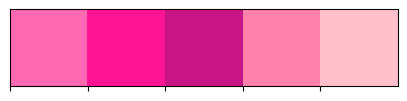

In [ ]:
# Custom Pink Palette
pink_palette = ["#FF69B4", "#FF1493", "#C71585", "#FF80AB", "#FFC0CB"]
sns.set_palette(pink_palette)

# Display the palette
sns.palplot(sns.color_palette())

### Distribution by Gender

---



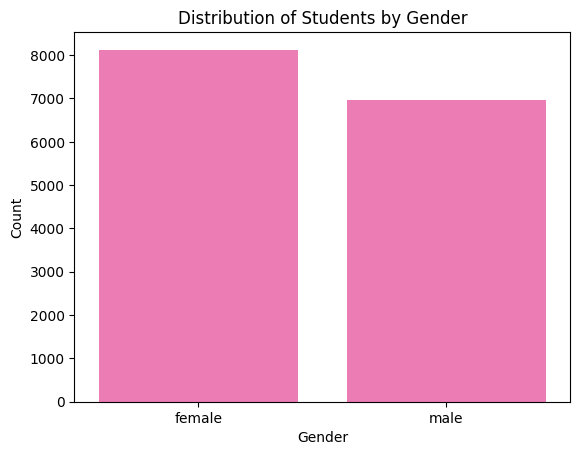

In [ ]:
#by gender
sns.countplot(data=waec_data, x="gender", order=waec_data["gender"].value_counts().index, color='#FF69B4')

plt.title("Distribution of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Distribution by School Type


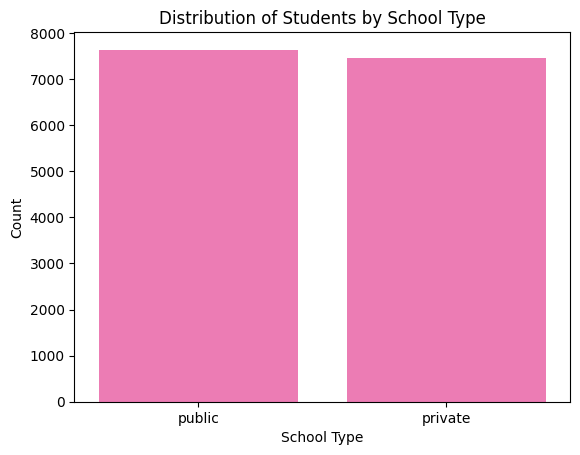

In [ ]:
#by school type
sns.countplot(data=waec_data, x="school_type", order=waec_data["school_type"].value_counts().index, color='#FF69B4')

plt.title("Distribution of Students by School Type")
plt.xlabel("School Type")
plt.ylabel("Count")
plt.show()

### Distribution by Student track


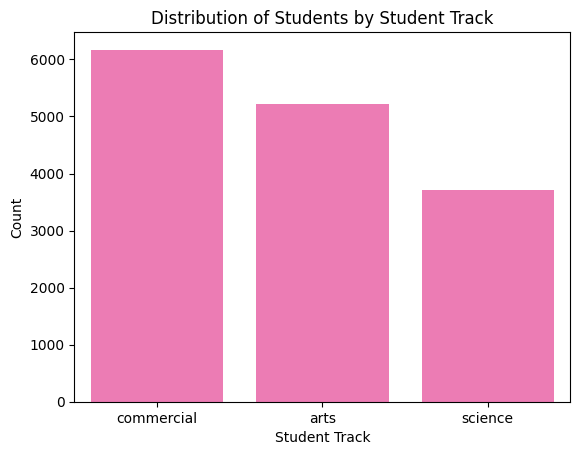

In [ ]:
#Distribution by student track
sns.countplot(data=waec_data, x="student_track", order=waec_data["student_track"].value_counts().index, color='#FF69B4')

plt.title("Distribution of Students by Student Track")
plt.xlabel("Student Track")
plt.ylabel("Count")
plt.show()

### Distribution by Resit status

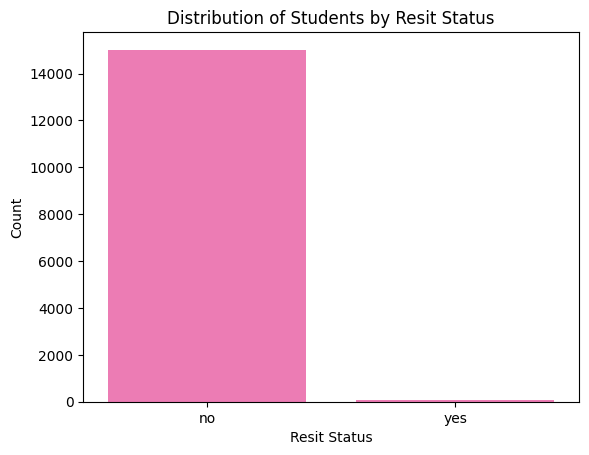

In [ ]:
#by is resit
sns.countplot(data=waec_data, x="is_resit", order=waec_data["is_resit"].value_counts().index, color='#FF69B4')

plt.title("Distribution of Students by Resit Status")
plt.xlabel("Resit Status")
plt.ylabel("Count")
plt.show()

In [ ]:
# Converting the passed benchmark to numeric (0/1)
waec_data['passed_benchmark'] = pd.to_numeric(
    waec_data['passed_benchmark'],
    errors='coerce')

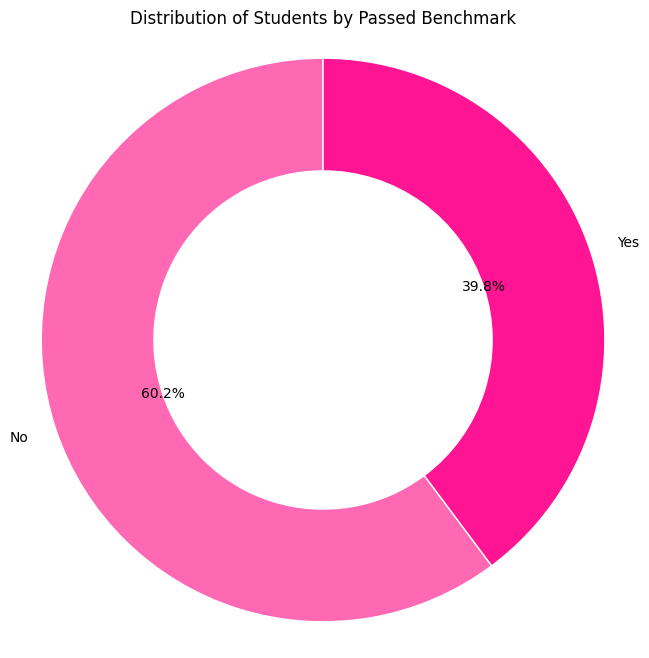

In [ ]:
benchmark_percentage = waec_data["passed_benchmark"].value_counts(normalize=True) * 100
benchmark_percentage = benchmark_percentage.round(2)


# Map 0 to 'No' and 1 to 'Yes'
labels_map = {0: 'No', 1: 'Yes'}
custom_labels = [labels_map[label] for label in benchmark_percentage.index]

plt.figure(figsize=(8, 8))
plt.pie(benchmark_percentage, labels=custom_labels, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.4, 'edgecolor': 'w'})
plt.title("Distribution of Students by Passed Benchmark")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

From the chart above we  it shows that 39.8% of the students actually passed the bench of scoring up to five credit, maths and English inclusive


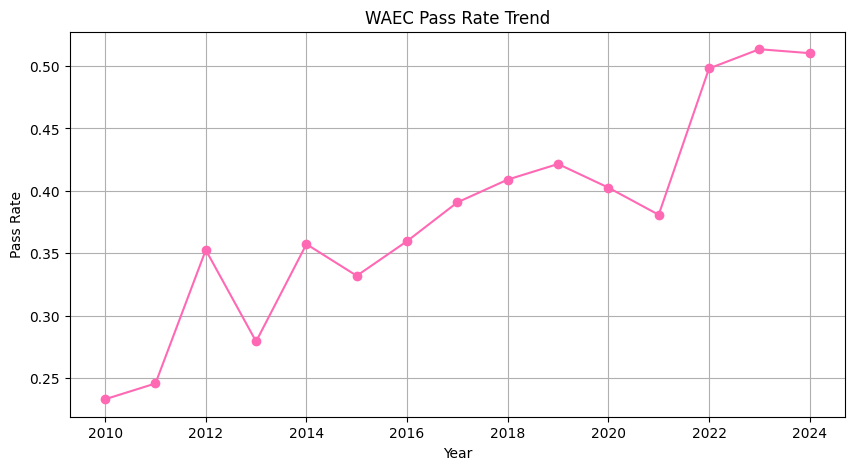

In [ ]:
# Yearly trend of the students who met the passed benchmark|

# Calculate the mean 'passed_benchmark' for each 'exam_year'
yearly_performance = waec_data.groupby('exam_year')['passed_benchmark'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_performance['exam_year'], yearly_performance['passed_benchmark'], marker='o')
plt.title("WAEC Pass Rate Trend")
plt.xlabel("Year")
plt.ylabel("Pass Rate")
plt.grid()

The yearly trend analysis reveals significant declines in WAEC student performance, particularly in 2013, 2015, and 2020. These drops are not random but align closely with major systemic, policy, and external disruptions across West Africa.

In 2013, performance declined sharply, which can be linked to stricter enforcement of examination integrity measures. WAEC introduced biometric verification and sanctioned over 100 schools for malpractice,collapsed hall in nigeria resulting into debt and severe injuries, Alos in Nigeria, Bokoharam Attacks in schools while also withholding a significant portion of results. These actions likely contributed to the lower pass rate.

Similarly, the drop in 2015 corresponds with widespread examination malpractice and mass result cancellations across multiple countries, continued insevurities in some member nations. Additionally, external disruptions such as the Ebola crisis in Liberia and Sierra Leone significantly affected school calendars and student preparedness, contributing to weaker performance outcomes.

The most recent major decline in 2020 aligns with the COVID-19 pandemic. School closures, delayed examinations, limited access to remote learning, and reported exam irregularities disrupted the academic cycle. These factors collectively contributed to reduced student readiness and overall performance.

Overall, the observed fluctuations suggest that WAEC performance is highly sensitive to systemic shocks, policy enforcement, and socio-economic disruptions. This highlights the importance of stable educational systems, consistent academic calendars, and equitable access to learning resources in maintaining student performance. [Read more](https://docs.google.com/document/d/1-jZR2te-QUefXMY0Ez3INWqz5OUyRp0uobtTcAEsctI/edit?usp=sharing)

 Top performing country

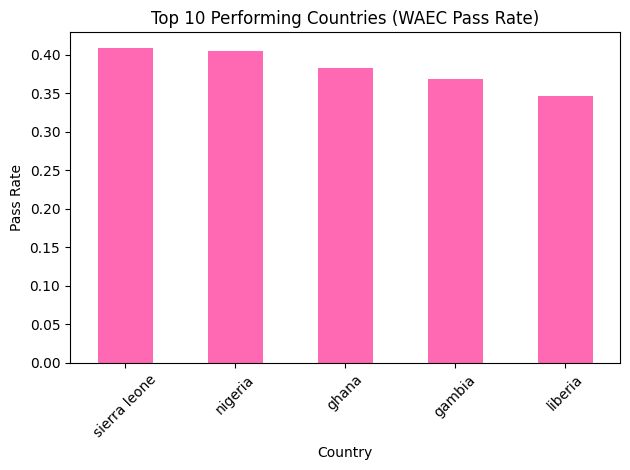

In [ ]:
country_performance = ( waec_data .groupby('country')['passed_benchmark'] .mean() .sort_values(ascending=False) )

top_countries = country_performance.head(10)

plt.figure()
top_countries.plot(kind='bar')

plt.title('Top 10 Performing Countries (WAEC Pass Rate)')
plt.xlabel('Country')
plt.ylabel('Pass Rate')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Aggregate by year and plot how performance changed from 2010 to 2024.



We will cheeck the various ddistribution across different categories

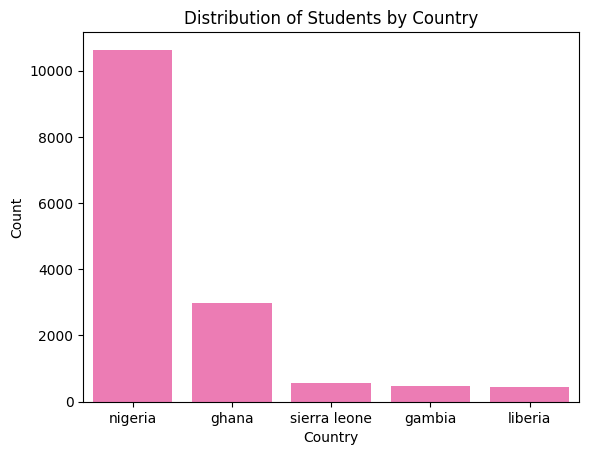

In [ ]:
#for country
sns.countplot(data=waec_data, x="country", order=waec_data["country"].value_counts().index, color='#FF69B4')

plt.title("Distribution of Students by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

Though Nigeria has the highest number of students that sit for Waec , Siera Leone is the top performing Country

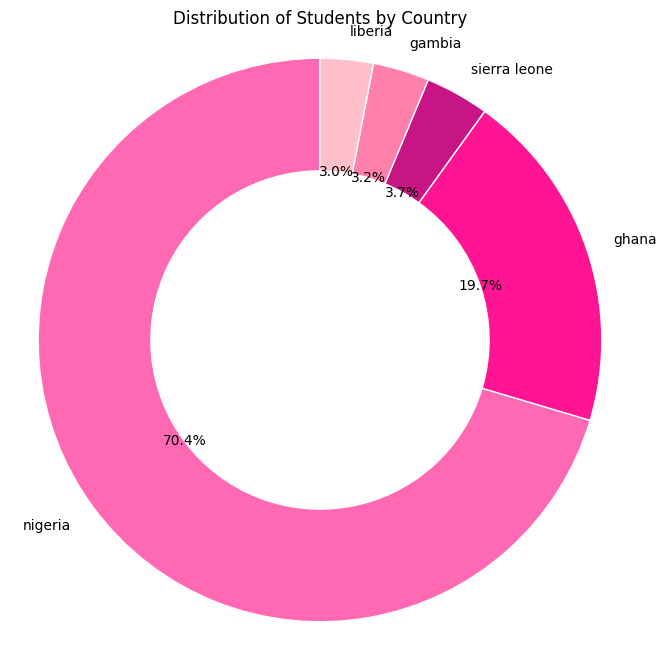

In [ ]:
#for country
country_counts = waec_data["country"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.4, 'edgecolor': 'w'}, colors=pink_palette)
plt.title("Distribution of Students by Country")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

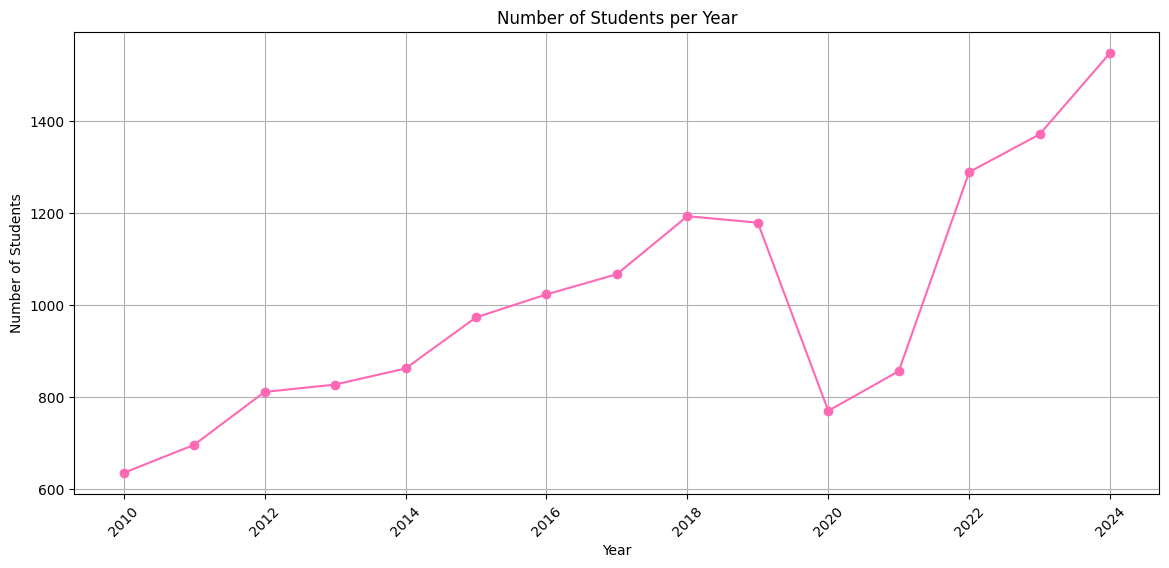

In [ ]:
year_counts = waec_data['exam_year'].value_counts().sort_index()

plt.figure(figsize=(14,6))

plt.plot(year_counts.index, year_counts.values, marker='o')

plt.title("Number of Students per Year")
plt.xlabel("Year")
plt.ylabel("Number of Students")

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

There has been a consistent increase in the number of students whao are taking waec from 2010 - 2019, execept in the year 2020 and 2021 which is as a result of the Covid 19 effect

comparing by exam type , since CBT was introduced in to While 2024 saw the start of the pilot program,
the full transition to 100% CBT for all WAEC exams was initially planned for 2026, we want to compare the performance
**of** students who wrote in Handwritten and CBT whch perform better and was able to pass the benchmark


In [ ]:
subset = waec_data[waec_data['exam_year'] >= 2023]

exam_type_perf = (
    subset
    .groupby('exam_type')['passed_benchmark']
    .mean()
)

print(exam_type_perf)

exam_type
cbt            0.500000
handwritten    0.513783
Name: passed_benchmark, dtype: float64


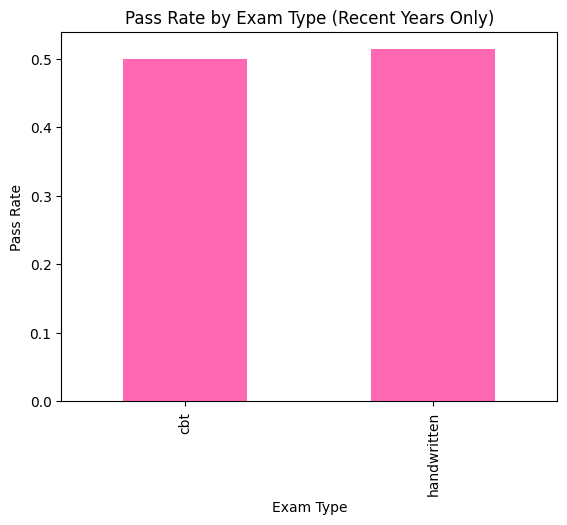

In [ ]:
exam_type_perf.plot(kind='bar', color='#FF69B4')

plt.title("Pass Rate by Exam Type (Recent Years Only)")
plt.ylabel("Pass Rate")
plt.xlabel("Exam Type")
plt.show()

The exam type has little or no effevt tin the perfomance of the student.

Knowing that the target column will be if the "passed_benchmark", we will check the mean pass rate per different categorical columns

In [ ]:
#per country
waec_data.groupby("country")["passed_benchmark"].mean().sort_values(ascending=False)

,passed_benchmark
country,
sierra leone,0.408680
nigeria,0.405174
ghana,0.382828
gambia,0.368852
liberia,0.346405


In [ ]:
#per school type
waec_data.groupby("school_type")["passed_benchmark"].mean()

,passed_benchmark
school_type,
private,0.481308
public,0.316486


In [ ]:
#per gender
waec_data.groupby("gender")["passed_benchmark"].mean()

,passed_benchmark
gender,
female,0.398105
male,0.397763


<Axes: title={'center': 'Performance by Gender'}, xlabel='gender'>

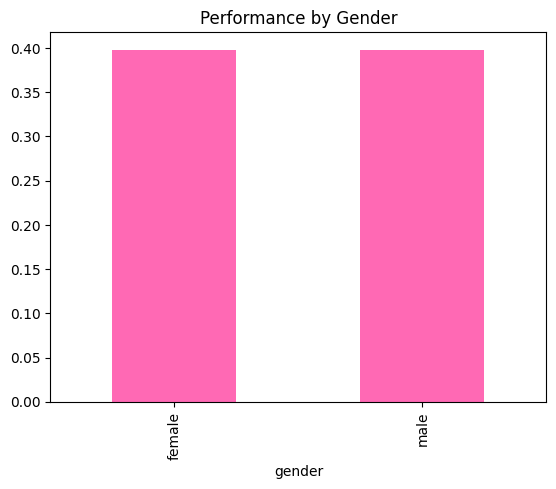

In [ ]:
gender_perf = waec_data.groupby('gender')['passed_benchmark'].mean()
gender_perf.plot(kind='bar', title='Performance by Gender')

In [ ]:
#per student track
waec_data.groupby('student_track')['passed_benchmark'].mean()

,passed_benchmark
student_track,
arts,0.387548
commercial,0.402755
science,0.404582


In [ ]:
#per region and show top ten regions

waec_data.groupby(['country', 'school_state_region'])['passed_benchmark'].mean().sort_values(ascending=False).head(10)

country  school_state_region
liberia  montserrado            0.490196
         bong                   0.468085
nigeria  ebonyi                 0.467797
         abia                   0.463158
gambia   kanifing               0.459016
ghana    central                0.455621
nigeria  enugu                  0.454545
         oyo                    0.452899
         ogun                   0.446494
         fct                    0.445783
Name: passed_benchmark, dtype: float64

Now we will check the time trend

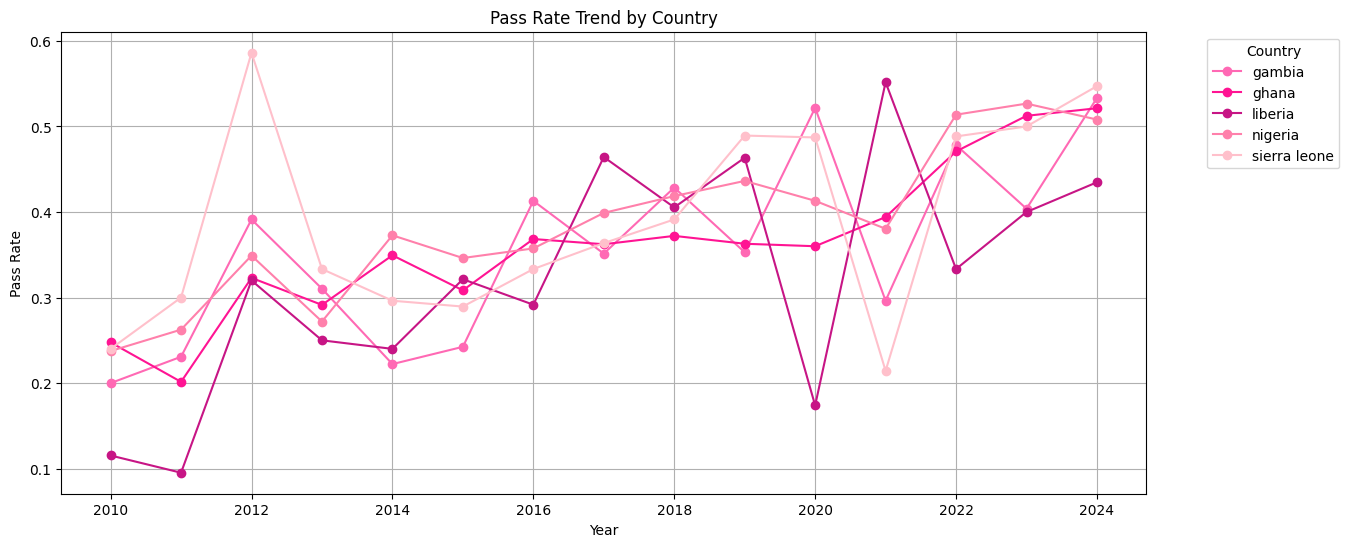

In [ ]:
#to check how the pass rate of coutries have changed over the yearss
pivot = (
    waec_data
    .groupby(['exam_year', 'country'])['passed_benchmark']
    .mean()
    .unstack()
)

plt.figure(figsize=(14,6))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)

plt.title("Pass Rate Trend by Country")
plt.xlabel("Year")
plt.ylabel("Pass Rate")

plt.legend(title="Country", bbox_to_anchor=(1.05, 1))
plt.grid(True)

plt.show()


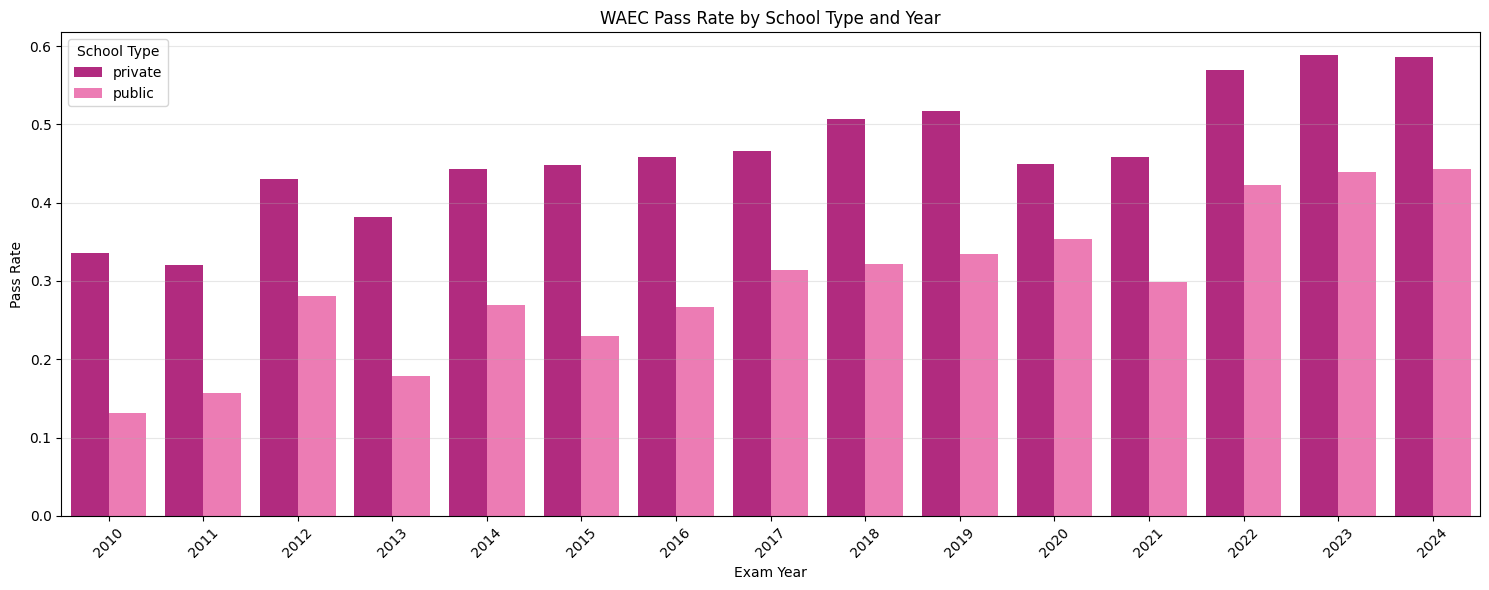

In [ ]:
#by sschool type
school_year = (
    waec_data
    .groupby(['exam_year', 'school_type'])['passed_benchmark']
    .mean()
    .reset_index()
)

plt.figure(figsize=(15,6))

sns.barplot(
    data=school_year,
    x="exam_year",
    y="passed_benchmark",
    hue="school_type",
    palette=["#C71585", "#FF69B4"],  # dark pink & complementary pink
    errorbar=None
)

plt.title("WAEC Pass Rate by School Type and Year")
plt.xlabel("Exam Year")
plt.ylabel("Pass Rate")
plt.xticks(rotation=45)
plt.legend(title="School Type")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Multi Variable Plot

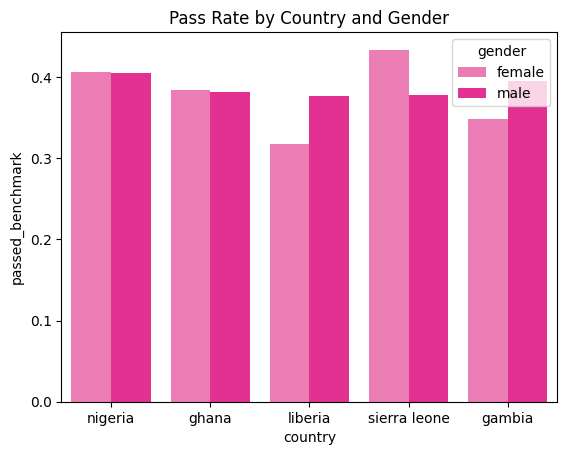

In [ ]:
#plot country and gender against passrate
sns.barplot(data=waec_data, x="country", y="passed_benchmark", hue="gender", errorbar=None)

plt.title("Pass Rate by Country and Gender")
plt.show()

Text(0.5, 1.0, 'Feature Correlation')

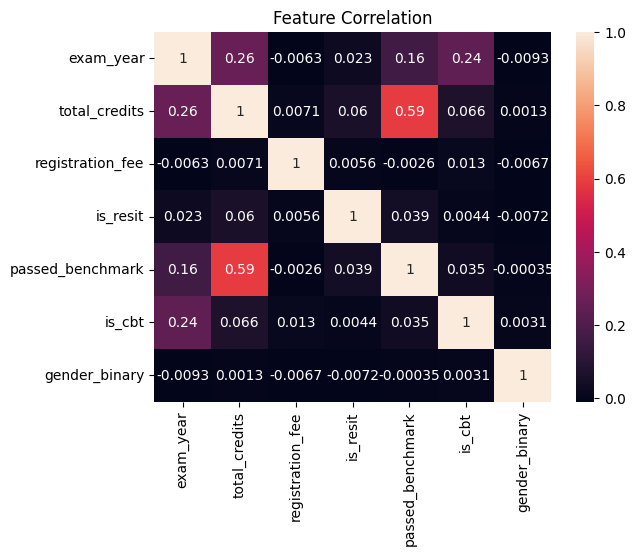

In [ ]:


corr = waec_data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")

# Data Preprocessing

Encoding the exam type, is resit and gender

In [ ]:
waec_data['is_resit']      = (waec_data['is_resit'] == 'yes').astype(int)
waec_data['is_cbt']        = (waec_data['exam_type'] == 'cbt').astype(int)
waec_data['gender_binary'] = waec_data['gender'].map({'male':1,'female':0})


# Modelling

### Feature Encoding

In [ ]:
waec_data.columns

Index(['country', 'exam_year', 'exam_type', 'student_track',
       'school_state_region', 'school_country_region', 'school_type',
       'subject_math', 'subject_english', 'subject_biology',
       'subject_chemistry', 'subject_physics', 'subject_further_math',
       'subject_agric', 'subject_literature', 'subject_government',
       'subject_history', 'subject_crs_irs', 'subject_yoruba_igbo_hausa',
       'subject_economics', 'subject_commerce', 'subject_accounts',
       'subject_phe', 'total_credits', 'registration_fee', 'gender',
       'is_resit', 'passed_benchmark', 'is_cbt', 'gender_binary'],
      dtype='object')

In [ ]:
categorical_cols = [
    "country",
    "school_type",
    "gender",
    "student_track",
    "is_resit"
]

numerical_cols = [
    "total_credits",
    "registration_fee"
]

X = waec_data[categorical_cols + numerical_cols]
y = waec_data["passed_benchmark"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [ ]:
categorical_cols = [
    "country",
    "school_type",
    "gender",
    "student_track",
    "is_resit"
]

numerical_cols = [
    "total_credits",
    "registration_fee"
]

# Do not assign X here directly, as it will be transformed later
# X = waec_data[categorical_cols + numerical_cols]
y = waec_data["passed_benchmark"]

# Define the preprocessor for both categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols) # Apply StandardScaler to numerical columns
    ]
)

In [ ]:
# Select the features from the original DataFrame before any transformation
FEATURES = ['country','is_resit','gender','school_type',
            'student_track','total_credits','registration_fee']

X = waec_data[FEATURES]
y = waec_data['passed_benchmark']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    stratify=y,          # keep same pass/fail ratio in both halves
    random_state=42      # same split every time
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# Apply preprocessing using the defined ColumnTransformer
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Step 4 — create and train the model using the processed data
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_processed, y_train)
print("Model trained!")

# Step 5 — make predictions on the test set using the processed data
y_pred = model.predict(X_test_processed)       # 0 or 1
y_prob = model.predict_proba(X_test_processed)[:, 1]  # probability score

# Step 6 — check results
print("\n--- How well did the model do? ---")
print(classification_report(y_test, y_pred,
      target_names=['Failed', 'Passed']))

print("ROC-AUC score:", round(roc_auc_score(y_test, y_prob), 4))
# ROC-AUC closer to 1.0 = better. 0.5 = random guessing

Training rows: 12080
Testing rows:  3020
Model trained!

--- How well did the model do? ---
              precision    recall  f1-score   support

      Failed       0.82      0.72      0.77      1818
      Passed       0.65      0.76      0.70      1202

    accuracy                           0.74      3020
   macro avg       0.73      0.74      0.73      3020
weighted avg       0.75      0.74      0.74      3020

ROC-AUC score: 0.8342


### Using Random Forest

In [ ]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [ ]:
# Using grid serach to determin the tune the parameter and determine optimal value for the model
param_grid_rf = {
    'model__n_estimators': [100, 200],       # number of trees
    'model__max_depth': [5, 10, 20],         # how deep trees grow
    'model__min_samples_split': [2, 5],      # splitting rule
    'model__class_weight': [None, 'balanced']
}

In [ ]:
# TRaining the grid Cv
grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['country',
                                                                          'school_type',
                                                                          'gender',
                                                                          'student_track',
                                                                          'is_resit']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['total_credits',
                                                                          'registration_fee'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [5, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
# printing the best parameter
print("Best parameters:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Best parameters: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: 0.851834301415054


In [ ]:
# Evaluting the result
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Failed', 'Passed']))
print("ROC-AUC score:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

      Failed       0.79      0.75      0.77      1818
      Passed       0.65      0.69      0.67      1202

    accuracy                           0.73      3020
   macro avg       0.72      0.72      0.72      3020
weighted avg       0.73      0.73      0.73      3020

ROC-AUC score: 0.8294


From our model,logistics regression perform slightly better than Random forest trying out XGBoost to test if it will perform better using this code

In [ ]:
# creating pipeline
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',   # avoids warning
        use_label_encoder=False
    ))
])

In [ ]:
# Performing grid
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

In [ ]:
# Grid search CV}
grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['country',
                                                                          'school_type',
                                                                          'gender',
                                                                          'student_track',
                                                                          'is_resit']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['total_credits',
                                                                          'registration_fee'])])),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [ ]:
# printing the best parameter
print("Best parameters:", grid_xgb.best_params_)
print("Best CV score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Best parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV score: 0.8535133483933859


In [ ]:
# Evaluation the score
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Failed', 'Passed']))
print("ROC-AUC score:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

      Failed       0.81      0.73      0.77      1818
      Passed       0.65      0.75      0.69      1202

    accuracy                           0.74      3020
   macro avg       0.73      0.74      0.73      3020
weighted avg       0.75      0.74      0.74      3020

ROC-AUC score: 0.8343


## Future Forecasting

We will ant to predict the performance of waec in the next years. ANd to do that we are using SARIMA

*   SARIMA is a time series used for forcasting and we will like to determine (How will WAEC performance change over the next 15 years?)



In [ ]:
# Sarima work with date and since we do not have date we are going with year
# aggregating the data

waec_trend = (
    waec_data
    .groupby('exam_year')['passed_benchmark']
    .mean()
    .reset_index()
)

waec_trend.columns = ['year', 'passed_benchmark']

waec_data['exam_year'] = pd.to_datetime(waec_data['exam_year'],format ='%Y')
waec_trend.set_index('year', inplace=True)

plt.figure(figsize=(10, 6))
plt.plot( waec_trend.index, waec_trend['benchmark'], linewidth=3, c='deeppink')
plt.title("yearly passed_benchmark")
plt.xlabel("year")
plt.ylabel("benchmark")
plt.show()

Why are we checking for stationary data

1. Augmented Dickey-Fuller (ADF) test is a statistical test in time series analysis used to determine whether a given time series is stationary. A stationary time series has constant mean and variance over time, which is a core assumption in many time series models, including ARIMA.

Why Stationarity Matters?
In time series modeling, stationarity ensures that the model's performance is consistent over time. Non-stationary data can produce misleading forecasts and incorrect inferences.



In [ ]:
result = adfuller(waec_trend['passed_benchmark'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.4610901417118218
p-value: 0.5526642440604815


In [ ]:
# since p>0.05
waec_trend['diff'] = waec_trend['passed_benchmark'].diff()


In [ ]:
waec_trend['diff']

,diff
year,
2010,NaN
2011,0.012619
2012,0.106961
2013,-0.073328
2014,0.077986
2015,-0.025346
2016,0.027763
2017,0.031089
2018,0.018237


In [ ]:
# Splitting the test and train data
train = waec_trend.iloc[:-5]
test = waec_trend.iloc[-5:]

In [ ]:
# building  sarimas=x model
model = SARIMAX(train['passed_benchmark'],
                order=(1,1,1),
                seasonal_order=(0,0,0,0))

model_fit = model.fit()

In [ ]:
# Evaluating the model
pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

mae = mean_absolute_error(test['passed_benchmark'], pred)
print("MAE:", mae)

MAE: 0.06383572557975437


In [ ]:


# forcasting the for next 15 years
forecast = model_fit.get_forecast(steps=15)
forecast_df = forecast.summary_frame()

# Create a date range for the forecasted years, starting from the year after the last historical data point
last_historical_year = waec_trend.index.max()
forecast_years = pd.to_datetime(pd.date_range(start=str(last_historical_year + 1), periods=15, freq='Y').year, format='%Y')
forecast_df.index = forecast_years

forecast_df

passed_benchmark,mean,mean_se,mean_ci_lower,mean_ci_upper
2025-01-01,0.417734,0.045534,0.328489,0.506979
2026-01-01,0.420204,0.052924,0.316475,0.523934
2027-01-01,0.418603,0.065747,0.289740,0.547465
2028-01-01,0.419641,0.072777,0.277001,0.562281
2029-01-01,0.418968,0.081312,0.259599,0.578337
2030-01-01,0.419404,0.087748,0.247422,0.591387
2031-01-01,0.419121,0.094512,0.233881,0.604361
2032-01-01,0.419305,0.100351,0.222620,0.615990
2033-01-01,0.419186,0.106158,0.211121,0.627251
2034-01-01,0.419263,0.111484,0.200759,0.637767


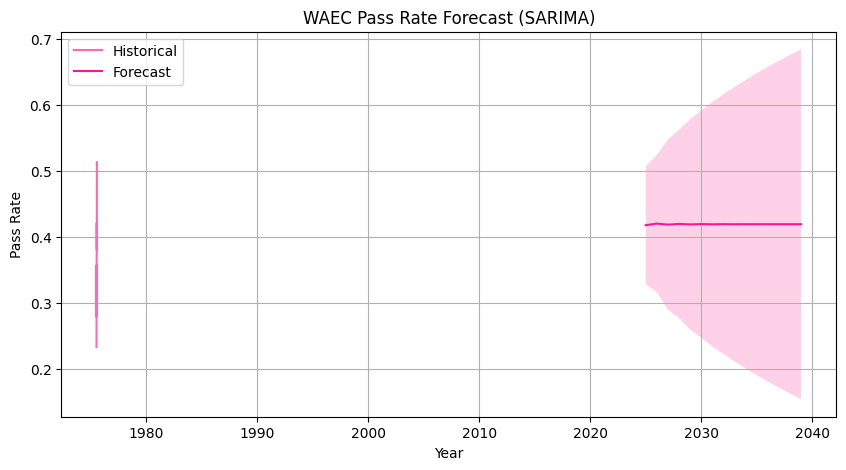

In [ ]:
# ploting the result
plt.figure(figsize=(10,5))

# Plot historical data
plt.plot(waec_trend.index, waec_trend['passed_benchmark'], label='Historical')

# Plot forecast data
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast')

# Fill between confidence intervals
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], alpha=0.3)

plt.title("WAEC Pass Rate Forecast (SARIMA)")
plt.xlabel("Year")
plt.ylabel("Pass Rate")
plt.legend()
plt.grid(True)
plt.show()

### The SARIMA forecast projects a national pass rate of approximately 65% by 2040.


Trying it out with prophet wich is a time series data developed by Meta

Prophet Forecast

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


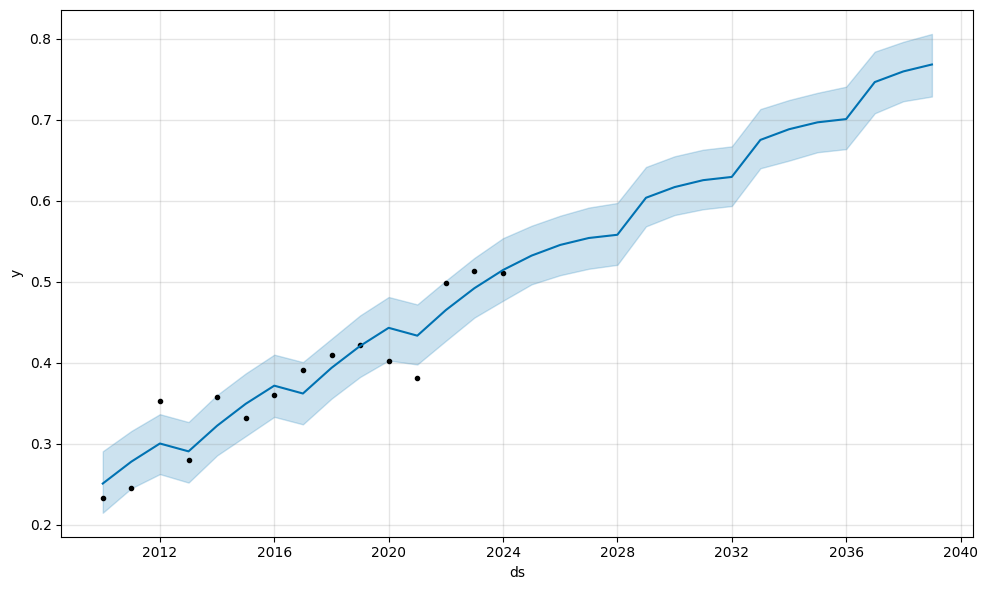

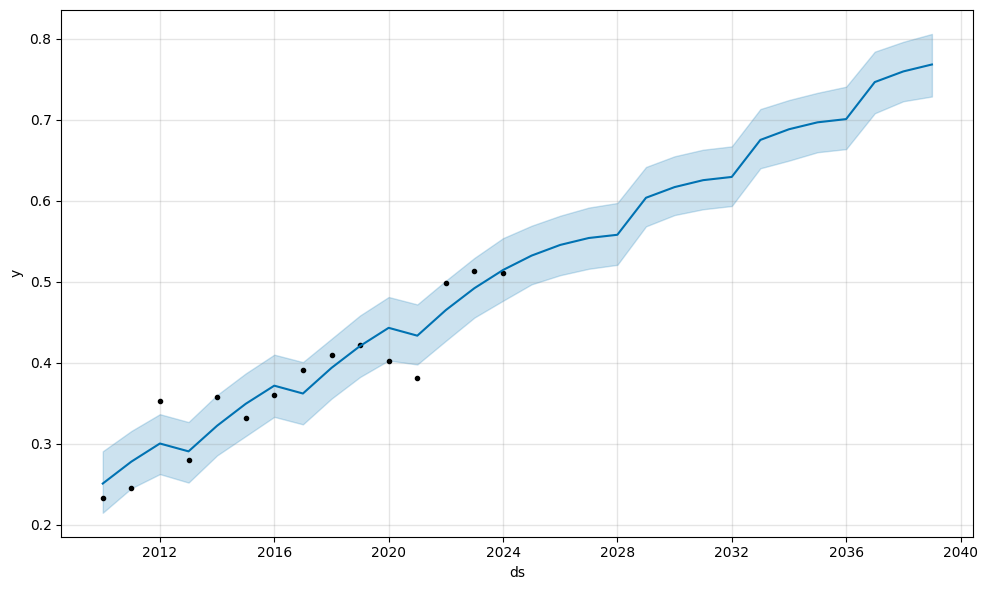

In [ ]:
prophet_df = waec_trend.reset_index()[['year', 'passed_benchmark']]
prophet_df.columns = ['ds', 'y']

# changing the ds column to th date time format
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=15, freq='Y')
forecast = model.predict(future)

model.plot(forecast)

###  The prophet forecast that WAEC pass rates are expected to improve consistently over time  approximately from 55% to 78 or 80% over the next 15 years.
